<div style="text-align: right;">
Santiago Escutia Ríos<br>
Jocelyn Atziri Jiménez Buenrostro<br> 
Valeria Estefanía Milke Loera<br> 
</div>

# **P02: Clasificación de Cáncer de Pulmón mediante Modelos de Machine Learning y Optimización Bayesiana**

### 1. Objetivos

**1.1 Objetivo general:** Desarrollar un modelo de aprendizaje supervisado capaz de clasificar la presencia de cáncer de pulmón basándose en hábitos y factores de riesgo, optimizando los hiperparámetros mediante procesos gaussianos.

**1.2 Objetivos específicos:**

- Explorar y limpiar el conjunto de datos

- Implementar y comparar tres arquitecturas
  1. Regresión Logística
  2. SVM (RBF)
  3. Multi-layer Perceptron (MLP).
- Diseñar un pipeline de preprocesamiento para el tratamiento de variables categóricas, numéricas y escalamiento de datos.

- Transformar las variables del dataset para que sean compatibles con modelos de machine learning.

- Utilizar Optimización Bayesiana para maximizar la métrica F1-Score en cada modelo.
______________

### 2. Marco teórico

**2.1 Regresión Logística:** Modelo de clasificación binaria que utiliza una función sigmoide para estimar la probabilidad de pertenencia a una clase. Es adecuado cuando la relación entre variables es aproximadamente lineal.

**2.2 Máquinas de Vectores de Soporte (SVM):** Modelo que busca encontrar un hiperplano óptimo que maximice la separación entre clases. En este proyecto se utiliza el kernel RBF, que permite capturar relaciones no lineales proyectando los datos a un espacio de mayor dimensión.

**2.3 Redes Neuronales (MLP):** Modelo inspirado en el cerebro humano que utiliza capas de neuronas interconectadas. Es capaz de aprender patrones complejos mediante el proceso de retropropagación.

**2.4 Kernels:** Funciones que permiten transformar los datos a espacios de mayor dimensión para facilitar la separación entre clases. El kernel RBF es uno de los más utilizados para problemas no lineales.

**2.5 Métricos para clasificación:**

Se utiliza el F1-score, que una combinación entre:

- Precisión (precision)
- Sensibilidad (recall)

Es especialmente importante en problemas médicos, donde los falsos negativos pueden ser críticos.

**2.6 Hiperparámetros:** Son parámetros del modelo que no se aprenden automáticamente, sino que deben ser definidos previamente.

- C en SVM
- Alpha en MLP
- Número de capas en redes neuronales

**2.7 Optimización Bayesiana:** Método eficiente para optimizar hiperparámetros utilizando procesos gaussianos. A diferencia de GridSearch, evalúa de forma inteligente qué combinaciones probar, reduciendo el tiempo de cómputo y mejorando los resultados.

**2.8 Tema del proyecto:** Clasificación del riesgo de cáncer de pulmón a partir de hábitos, estilo de vida y síntomas, utilizando modelos de aprendizaje automático optimizados mediante técnicas avanzadas de búsqueda de hiperparámetros.
_______

### 3. Análisis del dataset 

**3.1 Origen del conjunto de datos**

Los datos fueron obtenidos de la plataforma Kaggle, específicamente del dataset "Lung Cancer Prediction" publicado por la usuaria Nancy Al Aswad. Originalmente, la información proviene de un sistema de encuestas diseñado para identificar patrones de riesgo.

**3.2 Contenido**

El dataset está conformado por 309 registros y 16 variables asociadas a hábitos, enfermedades y características generales del paciente. Entre las variables principales se encuentran: 
- Género
- Edad
- Consumo de alcohol y tabaco
- Presencia de enfermedades crónicas, ansiedad, etc. 
- Síntomas (estornudos, fatiga, etc.)
- Variable objetivo: presencia de cáncer

**3.3 Información proporcionada por las muestras**

Cada registro representa a un individuo y describe:

- Características demográficas
- Hábitos de riesgo
- Síntomas
- Presencia de cáncer de pulmón

Esto permite identificar patrones entre factores de riesgo y la enfermedad.

**3.4 Lo que se pretende analizar**

Se busca analizar la relación entre los factores de riesgo y la presencia de cáncer de pulmón, con el objetivo de construir un modelo que prediga correctamente la enfermedad.

**3.5 Transformaciones realizadas**

- "LUNG_CANCER:" Variable objetivo del modelo. Se transformó de valores categóricos "YES" y "NO" a valores numéricos 1 y 0.

- "GENDER:" Se transformó de valores categóricos "M" y "F" a valores binarios 1 y 0.

- Variables binarias: Todas las variables de síntomas y hábitos fueron convertidas de 1 = No y 2 = Sí a 0 = No y  1 = Sí.

- Variables numéricas: Se aplicó StandardScaler a todas las variables predictoras, con el fin de estandarizar los datos media 0 y varianza 1.

**3.6 Resultados esperados**

Se espera obtener un modelo capaz de:

- Identificar correctamente a pacientes con riesgo de cáncer
- Detectar patrones importantes entre hábitos y enfermedad
- Maximizar el F1-score, equilibrando precisión y sensibilidad
- Reducir falsos negativos
_______

### 4. Implementación del modelo

**4.1 Carga y limpieza de datos** 

In [16]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
!pip install scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn import set_config

In [5]:
df = pd.read_csv('slc.csv')
df = df.drop_duplicates()
df.columns = df.columns.str.strip()

In [6]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [7]:
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES':1, 'NO':0})
df['GENDER'] = df['GENDER'].map({'M':1, 'F':0})

# variables binarias
binary_cols = df.columns.drop(['GENDER','AGE','LUNG_CANCER'])
df[binary_cols] = df[binary_cols].replace({1:0, 2:1})

In [8]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


In [9]:
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

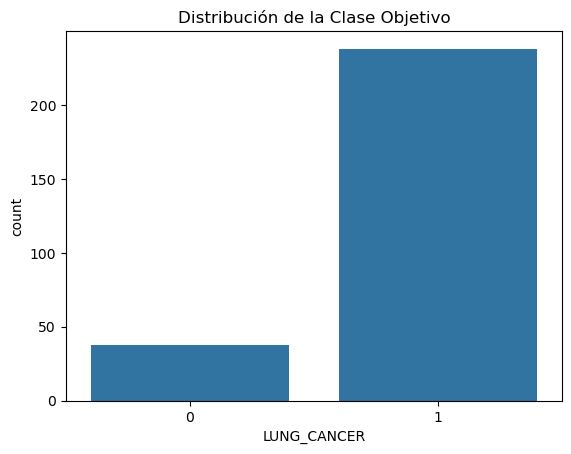

In [10]:
sns.countplot(x='LUNG_CANCER', data=df)
plt.title('Distribución de la Clase Objetivo')
plt.show()

**4.2 Definición de los tres modelos**

In [11]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_setup = {
    'Regresión Logística': {
        'model': LogisticRegression(solver='saga', max_iter=5000), # SAGA es mejor para L1/L2
        'params': {'clf__C': Real(1e-3, 1e2, prior='log-uniform')}
    },
    'SVM (RBF)': {
        'model': SVC(kernel='rbf', probability=True, max_iter=5000),
        'params': {
            'clf__C': Real(1e-2, 1e3, prior='log-uniform'),
            'clf__gamma': Real(1e-4, 1e-1, prior='log-uniform')
        }
    },
    'MLP (Red Neuronal)': {
        # Aumentamos max_iter a 2000 y habilitamos early_stopping
        'model': MLPClassifier(max_iter=2000, early_stopping=True, random_state=42),
        'params': {
            'clf__hidden_layer_sizes': Integer(10, 100),
            'clf__alpha': Real(1e-5, 1e-1, prior='log-uniform'),
            'clf__learning_rate_init': Real(1e-4, 1e-2, prior='log-uniform')
        }
    }
}

final_results = []

**4.3 Optimización Bayesiana**

In [22]:
final_results = []

for name, setup in models_setup.items():
    pipe = Pipeline([('scaler', StandardScaler()),('clf', setup['model'])])

    # Redujimos n_iter a 15 para que sea más rápido pero efectivo
    opt = BayesSearchCV(pipe, setup['params'], n_iter=15, cv=cv_strategy, scoring='f1', random_state=42, n_jobs=-1)
    opt.fit(X, y)

    scores = cross_val_score(opt.best_estimator_, X, y, cv=cv_strategy, scoring='f1')

    final_results.append({
        'Modelo': name,
        'F1_Media': scores.mean(),
        'F1_Std': scores.std(),
        'Params': opt.best_params_
    })

### 5. Pipeline

- Entrada de datos: Carga del dataset original.
- Limpieza de datos: Análisis de las variables, eliminación de registros duplicados y revisión de consistencia en los nombres de las variables.
- Transformación de variables:
1. Conversión de variables categóricas y binarias a formato numérico (0/1).
2. Codificación de la variable objetivo.
- Escalamiento de datos: Aplicación de StandardScaler a todas las variables predictoras, con el fin de estandarizar los datos, fundamental para modelos como SVM y redes neuronales.
- Modelado: Implementación de modelos de clasificación (Regresión Logística, SVM con kernel RBF y MLP), y optimización de hiperparámetros mediante búsqueda bayesiana.
- Evaluación: Validación del desempeño de los modelos mediante Stratified K-Fold Cross Validation, utilizando la métrica F1 para comparar resultados.

In [20]:
set_config(display='diagram')

pipeline_visual = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression()) 
])

pipeline_visual

Pipeline(steps=[('scaler', StandardScaler()), ('clf', LogisticRegression())])

### 6. Resultados

In [21]:
results_df = pd.DataFrame(final_results)
print("\n--- RESULTADOS CONCLUYENTES ---")
print(results_df[['Modelo', 'F1_Media', 'F1_Std']])


--- RESULTADOS CONCLUYENTES ---
                Modelo  F1_Media    F1_Std
0  Regresión Logística  0.954540  0.010555
1            SVM (RBF)  0.954018  0.014584
2   MLP (Red Neuronal)  0.940822  0.010511


**6.1 Análisis de Resultados**

Tras realizar validación cruzada con 5 folds, se observa que todos los modelos presentan un desempeño alto (F1 ≈ 0.94–0.95), lo que indica que el problema es altamente predecible con las variables disponibles.

La Regresión Logística obtuvo el mejor resultado, lo que sugiere que la relación entre las variables y la variable objetivo es aproximadamente lineal.

El modelo SVM con kernel RBF mostró un desempeño muy similar, confirmando que no existe una mejora significativa al introducir no linealidad, aunque presenta una mayor variabilidad en los resultados, aunque muy ligera.

Por otro lado, el modelo MLP tuvo un desempeño ligeramente inferior, lo cual puede explicarse porque las redes neuronales requieren una mayor cantidad de datos para generalizar correctamente.

**6.2 Interpretación métrico F1-Score**

El F1-score combina precisión y recall, permitiendo evaluar el modelo de forma balanceada. En este proyecto es el métrico más adecuado, ya que busca detectar correctamente casos de cáncer sin generar demasiados errores.

Los valores cercanos a 0.95 indican un excelente desempeño, mostrando que los modelos logran un buen equilibrio entre identificar casos positivos y evitar clasificaciones incorrectas.
______________________

### 7. Conclusión

El presente proyecto tuvo como objetivo desarrollar y comparar distintos modelos de clasificación para predecir la presencia de cáncer de pulmón a partir de variables relacionadas con hábitos y síntomas. Con base en los resultados obtenidos, se puede concluir que este objetivo fue cumplido de forma adecuada. 

El preprocesamiento de datos resultó fundamental para el desempeño correcto de los modelos. La transformación de variables categóricas a numéricas, la estandarización de los datos y la limpieza del dataset permitieron que los algoritmos trabajaran de manera eficiente y no presentaran sesgos. 

En cuanto a los modelos implementados, las tres arquitecturas utilizadas obtuvieron valores altos de F1-score (cercanos a 0.95). Esto indica que el dataset contiene información relevante y suficiente para identificar patrones asociados al cáncer de pulmón.

Particularmente, la Regresión Logística presentó el mejor desempeño (F1 ≈ 0.95) y menor variabilidad, lo que sugiere una relación casi lineal entre las variables independientes y la variable objetivo. Además, este modelo destaca por su interpretabilidad, lo cual es especialmente importante en aplicaciones médicas. Por otra parte, el modelo SVM (RBF) mostró resultados similares, lo que indica que la introducción de no linealidad en este caso no aporta una mejora significativa. En contraste, el modelo MLP (Red Neuronal) obtuvo un desempeño ligeramente inferior. Esto puede explicarse debido al tamaño reducido del dataset, pues este tipo de modelos requiere una mayor cantidad de datos para aprovechar completamente su capacidad.

Adicionalmente, el uso de Optimización Bayesiana permitió encontrar configuraciones eficientes de hiperparámetros sin necesidad de realizar una búsqueda exhaustiva, optimizando así el tiempo de entrenamiento y mejorando el desempeño general de los modelos.

En conjunto, los resultados obtenidos cumplen con los objetivos específicos planteados, ya que se logró realizar una correcta exploración y limpieza del dataset, implementar, optimizar y evaluar distintos modelos de clasificación, así como comparar su desempeño de manera adecuada. Finalmente, se concluye que el problema de predicción de cáncer de pulmón para este dataset se puede abordar eficazmente con modelos relativamente simples, destacando la importancia de una correcta preparación de los datos. Sin embargo, para mejorar aún más los resultados, sería recomendable contar con un dataset de mayor tamaño para capturar mejor la complejidad del problema.
_______

### 8. Referencias

- Alaswad, N. (2022). Lung Cancer Dataset. Kaggle. https://www.kaggle.com/datasets/nancyalaswad90/lung-cancer

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). An Introduction to Statistical Learning: with Applications in R. Springer.

- Head, T., Mechhal, M., Bonventre, G., & Louppe, G. (2018). Scikit-Optimize: Sequential model-based optimization in Python. https://scikit-optimize.github.io/